# Clasificador usando el algortimo de Árbol de Decisión (*Decision Tree*)

## 1. Importar las librerías

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Cargar el Dataset Iris

El conjunto de datos IRIS es probablemente el primer conjunto de datos que los estudiantes y principiantes experimentan mientras aprenden ciencia de datos y aprendizaje automático (*machine learning*). El conjunto de datos IRIS es simple y fácil de entender, y ha sido utilizado por estudiantes, investigadores y profesionales durante décadas para aprender los conceptos básicos de clasificación y análisis de datos. 

El conjunto de datos IRIS fue publicado en 1936 por el estadístico británico Ronald A. Fisher en el artículo “**El uso de mediciones múltiples en problemas taxonómicos**” y, desde entonces, el conjunto de datos IRIS se ha hecho conocido como el “Hola mundo” del aprendizaje automático (ML) porque proporciona una introducción muy efectiva a los conjuntos de datos y algoritmos del mundo real para los estudiantes.

![Descripción](iris.png)

El conjunto de datos Iris es un conjunto de datos de **150 filas** y **4 características** de medidas de flores de iris (**longitud del sépalo, ancho del sépalo, longitud de los pétalos, ancho de los pétalos**) en **tres especies** — **Setosa, Versicolor y Virginica**. La longitud y el ancho de los pétalos son las dos características más correlacionadas con las especies, lo que las convierte en los predictores más fuertes. Es el primer conjunto de datos estándar para aprender la clasificación porque es pequeño, limpio y no requiere limpieza de datos antes del modelado.

Las cuatro características medidas (en centímetros) para cada flor:
Estas son las medidas que utilizamos para hacer nuestra predicción. Puedes pensar en ellos como las piezas de un rompecabezas.
- Longitud del sépalo (cm): El sépalo es la parte de la flor que protege el brote antes de florecer. Esta característica es una medida de la longitud del sépalo. 
- Ancho del sépalo (cm): es una medida del ancho del sépalo.
- Longitud del pétalo (cm): El pétalo es la parte muy colorida de la flor. Esta es una medida de cuánto tiempo dura. 
- Ancho del pétalo (cm): es una medida del ancho del pétalo. 

![Descripción](iris_dimensions.png)

Tomado de: [Guvi](https://www.guvi.in/blog/iris-dataset-explained-features/)

Las clases objetivo (los resultados): 
- Iris Setosa (0): Esta especie se distingue claramente de las otras dos especies de Iris, por lo que puede considerarse como el "modo fácil" de este conjunto de datos para un clasificador. 
- Iris Versicolor (1): Esta especie es muy similar a Virginica, lo que significa que es más difícil distinguirlas. ¡Ahí radica la verdadera dificultad!
- Iris Virginica (2): La tercera especie que es más probable que se confunda con Versicolor basándose únicamente en las medidas de dimensiones. 

In [4]:
# Cargar el dataset
# iris = load_iris()
# iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# iris_df = iris.frame
# iris_df.to_csv('dataset/iris.csv')
iris_df = pd.read_csv('dataset/iris.csv', header=0, index_col=0)

In [5]:
# Nombres de las características
# iris.feature_names

In [6]:
iris_df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

## 3. Análisis Exploratorio de Datos (EDA)

In [7]:
# Dimensiones del dataset
iris_df.shape

(150, 5)

In [8]:
# Tipos de datos del dataset
iris_df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

In [9]:
# Primeros registros del dataset
iris_df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
# Últimos registros del dataset
iris_df.tail(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [11]:
# Descripción del dataset
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [12]:
# Iris Setosa(0)
iris_df[iris_df.target == 0].describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,50.00000,50.000000,50.000000,50.000000,50.0
mean,5.00600,3.428000,1.462000,0.246000,0.0
std,0.35249,0.379064,0.173664,0.105386,0.0
min,4.30000,2.300000,1.000000,0.100000,0.0
25%,4.80000,3.200000,1.400000,0.200000,0.0
50%,5.00000,3.400000,1.500000,0.200000,0.0
75%,5.20000,3.675000,1.575000,0.300000,0.0
max,5.80000,4.400000,1.900000,0.600000,0.0


In [13]:
# Iris Versicolor(1)
iris_df[iris_df.target == 1].describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,50.000000,50.000000,50.000000,50.000000,50.0
mean,5.936000,2.770000,4.260000,1.326000,1.0
std,0.516171,0.313798,0.469911,0.197753,0.0
min,4.900000,2.000000,3.000000,1.000000,1.0
25%,5.600000,2.525000,4.000000,1.200000,1.0
50%,5.900000,2.800000,4.350000,1.300000,1.0
75%,6.300000,3.000000,4.600000,1.500000,1.0
max,7.000000,3.400000,5.100000,1.800000,1.0


In [14]:
# Iris Virginica(2)
iris_df[iris_df.target == 2].describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,50.00000,50.000000,50.000000,50.00000,50.0
mean,6.58800,2.974000,5.552000,2.02600,2.0
std,0.63588,0.322497,0.551895,0.27465,0.0
min,4.90000,2.200000,4.500000,1.40000,2.0
25%,6.22500,2.800000,5.100000,1.80000,2.0
50%,6.50000,3.000000,5.550000,2.00000,2.0
75%,6.90000,3.175000,5.875000,2.30000,2.0
max,7.90000,3.800000,6.900000,2.50000,2.0


array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>],
       [<Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

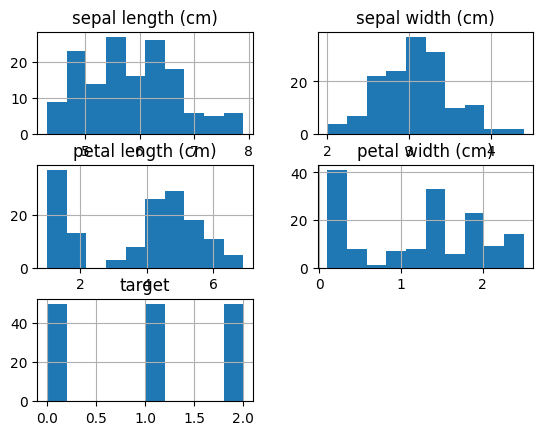

In [15]:
iris_df.hist()

array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>],
       [<Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

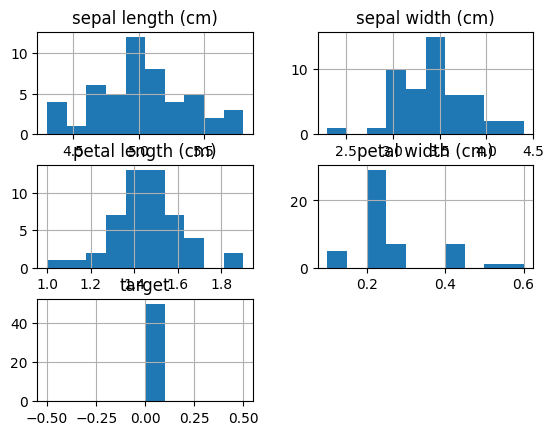

In [16]:
# Histograma para la clase setosa (0)
iris_df[iris_df.target==0].hist()

array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>],
       [<Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

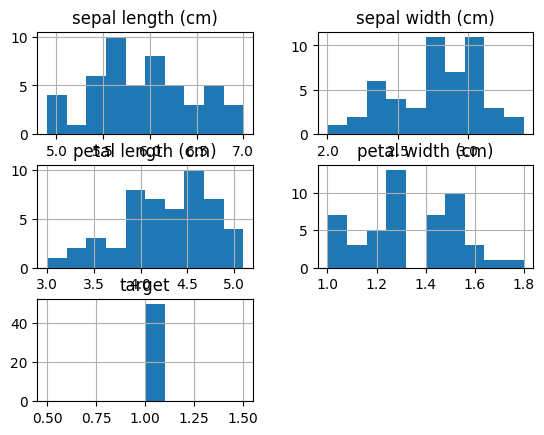

In [17]:
# Histograma para la clase Versicolor (1)
iris_df[iris_df.target==1].hist()

array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>],
       [<Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

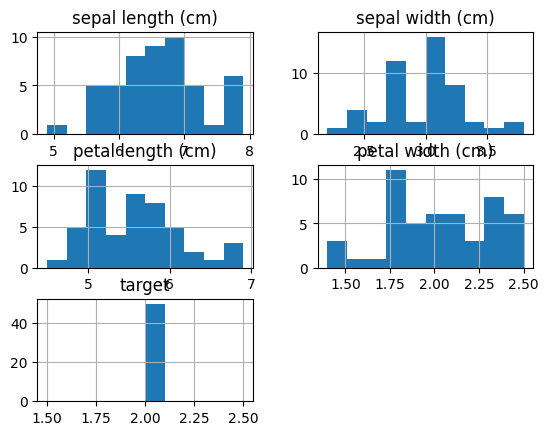

In [18]:
# Histograma para la clase Virginica (2)
iris_df[iris_df.target==2].hist()

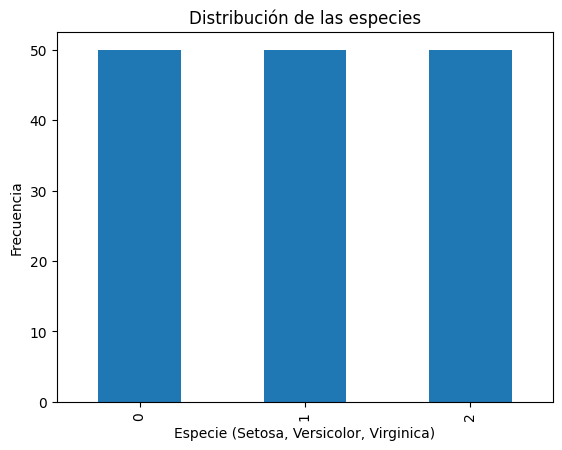

In [19]:
iris_df['target'].value_counts().plot(kind='bar')
plt.title('Distribución de las especies')
plt.xlabel('Especie (Setosa, Versicolor, Virginica)')
plt.ylabel('Frecuencia')
plt.show()


## Verificar valores faltantes 

In [20]:
iris_df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [21]:
print("Porcentaje de valores nulos ")
iris_df.isnull().mean()*100


Porcentaje de valores nulos 


sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
target               0.0
dtype: float64

# Correlación entre variables

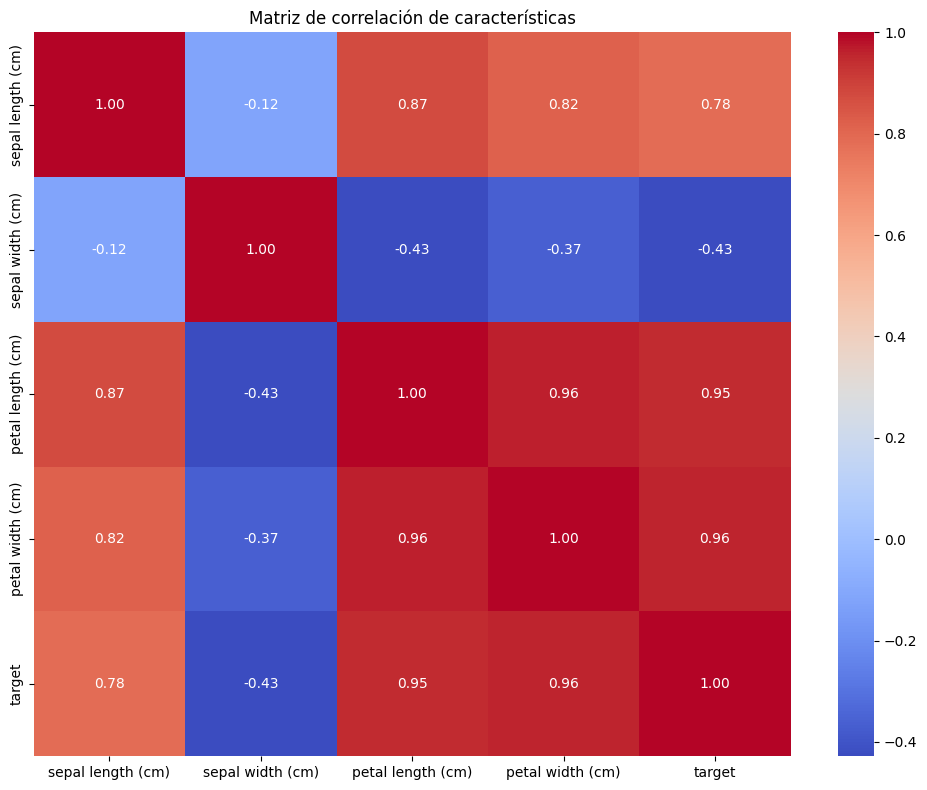

In [22]:
plt.figure(figsize=(10, 8))     # 10 x 8 pulgadas
sns.heatmap(iris_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación de características')
plt.tight_layout()
plt.show()

**Insights clave**: 
- Fuertemente positivo: (r > 0.8) petal_length <-> petal_width: r = 0.96 multicolineal
- Negativo: (r < -0.3) sepal_width <-> petal_length: r = -0.43

*¿Por qué es importante?* La correlación solo refleja relaciones lineales. Dos variables pueden estar fuertemente relacionadas de forma no lineal y aun así mostrar una correlación cercana a cero. Además, la correlación no implica causalidad. Las características altamente correlacionadas no aportan información nueva. Considere eliminar una. 

## Visualizar las distribuciones

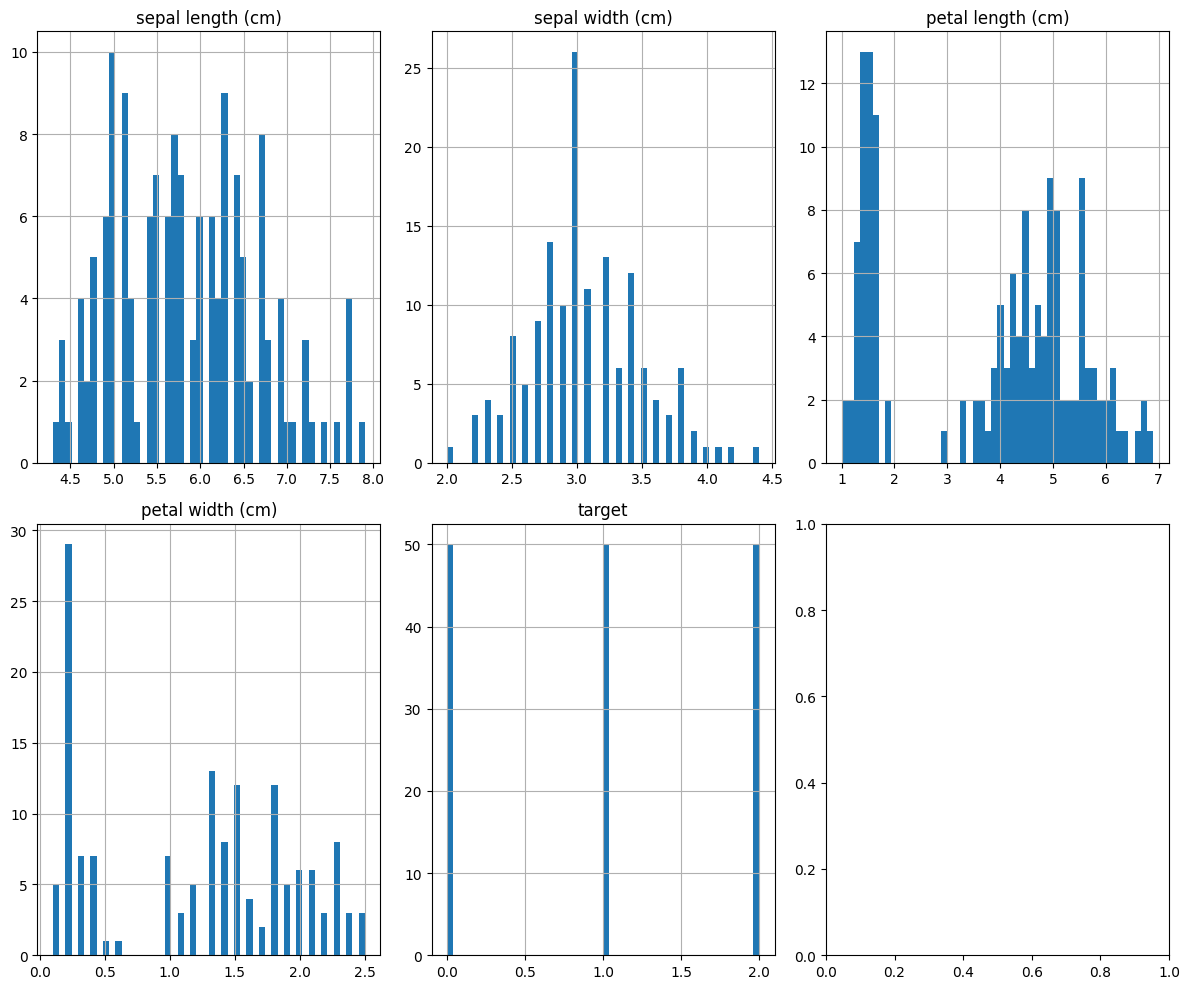

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(iris_df.columns):
    iris_df[col].hist(bins=50, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

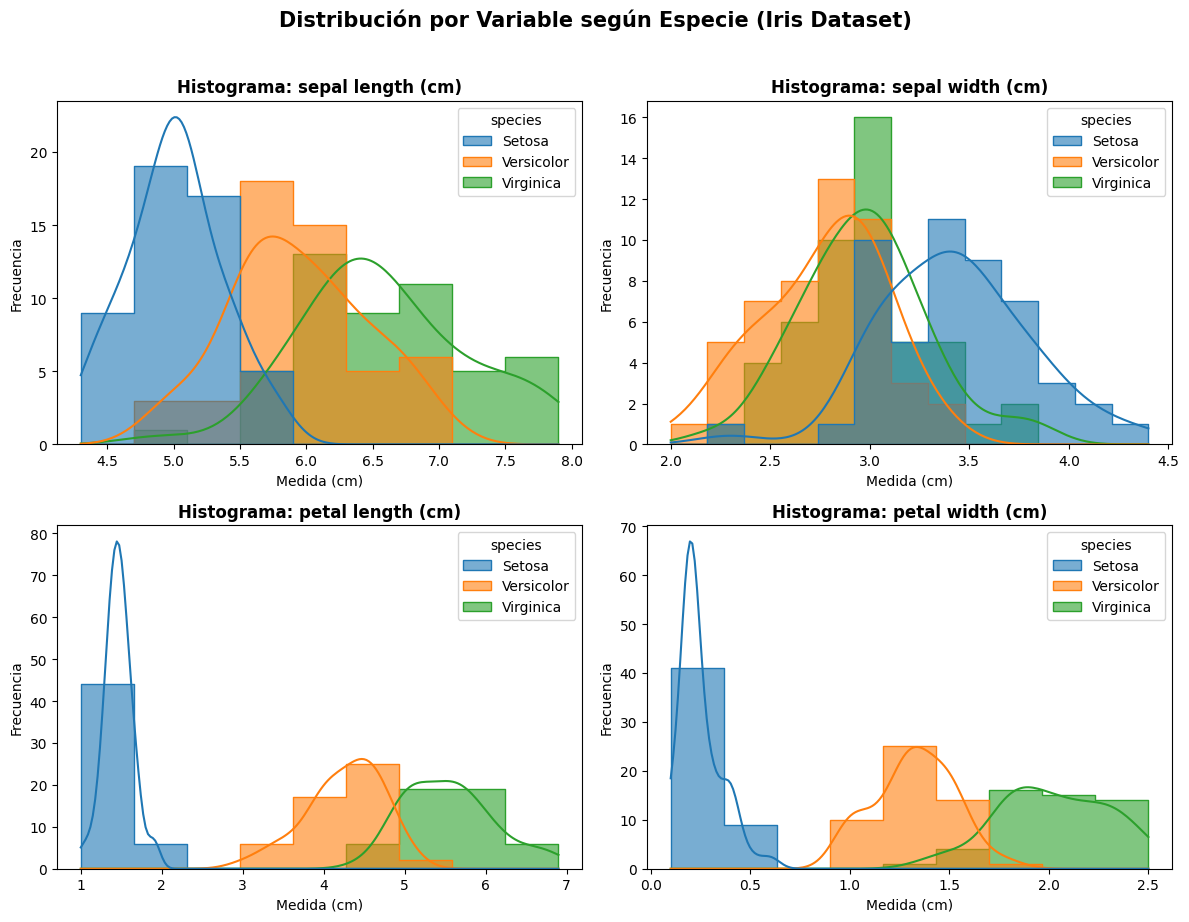

In [23]:
# Mapea los números de target a los nombres reales de las especies
target_names = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
iris_plot = iris_df.copy()
iris_plot['species'] = iris_plot['target'].map(target_names)

features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# Crear cuadrícula de 2x2 gráficos
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(
        data=iris_plot, 
        x=col, 
        hue='species', 
        kde=True,          # Agrega curva de densidad
        ax=axes[i], 
        palette='tab10', 
        element="step",
        alpha=0.6
    )
    axes[i].set_title(f'Histograma: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Medida (cm)')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución por Variable según Especie (Iris Dataset)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()